# Лабораторна робота №2
## NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних
**Студент:** Моторін Максим Сергійович  
**Група:** МІТ-31 
**Варіант:** 7  
**Предметна область:** Заряд акумулятора (X: Час, хв | Y: Заряд, %)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Налаштування відтворюваності та параметрів Варіанта 7
seed = 7
a = -0.65
b = 98.0
sigma = 1.5

rng = np.random.default_rng(seed)
print("Бібліотеки успішно імпортовано. Seed set to", seed)

Бібліотеки успішно імпортовано. Seed set to 7


In [2]:
# 1. Формуємо x (100 рівномірних значень від 0 до 20)
x = np.linspace(0, 20, 100)

# 2. Обчислюємо теоретичне y_hat, шум та спостережуване y_observed
y_hat = a * x + b
noise = rng.normal(loc=0, scale=sigma, size=x.size)
y_observed = y_hat + noise

# 3. Об'єднуємо у 2D-матрицю (стовпчики: x, y_hat, noise, y_observed)
matrix = np.column_stack((x, y_hat, noise, y_observed))

print("Форма (shape):", matrix.shape)
print("Размірність (ndim):", matrix.ndim)
print("Загальна кількість елементів (size):", matrix.size)
print("Тип даних (dtype):", matrix.dtype)

Форма (shape): (100, 4)
Размірність (ndim): 2
Загальна кількість елементів (size): 400
Тип даних (dtype): float64


**Пояснення NumPy атрибутів:**
* `shape = (100, 4)` означає, що матриця має 100 рядків та 4 стовпчики.
* `ndim = 2` вказує, що це двовимірний масив (матриця).
* `size = 400` показує загальну кількість елементів (100 * 4).
* `dtype = float64` означає, що дані збережені як числа з плаваючою крапкою високої точності.

In [3]:
# Читання через індекс і зріз
print("Перший рядок:", matrix[0, :])
print("Перші 5 значень y_observed:", matrix[:5, 3])

# Булева фільтрація (значення y_observed > 90)
high_charge = matrix[matrix[:, 3] > 90]
print("Кількість вимірів із зарядом > 90%:", len(high_charge))

# Оновлення копії (безпечно, без зміни вихідного масиву через view)
matrix_copy = matrix.copy()
matrix_copy[0, 3] = 99.9

# Агрегаційні характеристики для y_observed (axis=0)
y_obs = matrix[:, 3]
print("\nСтатистика y_observed:")
print(f"Min: {np.min(y_obs):.2f}")
print(f"Max: {np.max(y_obs):.2f}")
print(f"Mean: {np.mean(y_obs):.2f}")
print(f"Std: {np.std(y_obs):.2f}")

Перший рядок: [0.00000000e+00 9.80000000e+01 1.84523004e-03 9.80018452e+01]
Перші 5 значень y_observed: [98.00184523 98.31680517 97.32616695 96.27017285 96.7927413 ]
Кількість вимірів із зарядом > 90%: 62

Статистика y_observed:
Min: 81.95
Max: 99.09
Mean: 91.24
Std: 3.86


In [4]:
# Створення DataFrame
df = pd.DataFrame({
    "x": x,
    "y_true": y_hat,
    "noise": noise,
    "y_observed": y_observed,
    "group": pd.cut(x, bins=3, labels=["low", "medium", "high"])
})

print("--- Перші 5 рядків (head) ---")
print(df.head())
print("\n--- Форма таблиці ---")
print(df.shape)
print("\n--- Інформація про dtypes ---")
print(df.dtypes)
print("\n--- Метод info() ---")
df.info()
print("\n--- Описова статистика ---")
print(df.describe())

--- Перші 5 рядків (head) ---
          x     y_true     noise  y_observed group
0  0.000000  98.000000  0.001845   98.001845   low
1  0.202020  97.868687  0.448118   98.316805   low
2  0.404040  97.737374 -0.411207   97.326167   low
3  0.606061  97.606061 -1.335888   96.270173   low
4  0.808081  97.474747 -0.682006   96.792741   low

--- Форма таблиці ---
(100, 5)

--- Інформація про dtypes ---
x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object

--- Метод info() ---
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB

--- Описов

In [5]:
# Створюємо копію для очищення
df_dirty = df.copy()

# Штучно додаємо 3 пропуски та 1 дублікат
df_dirty.loc[5, "y_observed"] = np.nan
df_dirty.loc[15, "y_observed"] = np.nan
df_dirty.loc[25, "y_observed"] = np.nan
df_dirty = pd.concat([df_dirty, df_dirty.iloc[[0]]], ignore_index=True)

print("Кількість пропусків у стовпчиках:")
print(df_dirty.isna().sum())
print("Кількість дублікатів:", df_dirty.duplicated().sum())

# Видаляємо дублікат
df_cleaned = df_dirty.drop_duplicates().copy()

# Заповнюємо пропуски медіаною
median_val = df_cleaned["y_observed"].median()
df_cleaned["y_observed"] = df_cleaned["y_observed"].fillna(median_val)

print("Перевірка пропусків після очищення:", df_cleaned["y_observed"].isna().sum())
print("Форма очищеної таблиці:", df_cleaned.shape)

Кількість пропусків у стовпчиках:
x             0
y_true        0
noise         0
y_observed    3
group         0
dtype: int64
Кількість дублікатів: 1
Перевірка пропусків після очищення: 0
Форма очищеної таблиці: (100, 5)


**Пояснення вибору медіани:**  
Медіана була обрана для заповнення пропусків, оскільки вона є стійкою до можливих викидів і шуму у даних на відміну від середнього арифметичного.

In [6]:
# Приклад loc та iloc
print("Доступ через loc (фільтр):")
print(df_cleaned.loc[df_cleaned["y_observed"] < 85, ["x", "y_observed"]].head(3))

print("\nДоступ через iloc (перші 3 рядки, 2 стовпчики):")
print(df_cleaned.iloc[0:3, 0:2])

# Групування за інтервалами часу (group)
summary = df_cleaned.groupby("group", observed=False).agg(
    mean_y_observed=("y_observed", "mean"),
    std_y_observed=("y_observed", "std"),
    count_size=("y_observed", "size"),
    count_valid=("y_observed", "count")
)

print("\n--- Агрегована таблиця ---")
print(summary)

Доступ через loc (фільтр):
            x  y_observed
96  19.393939   83.457600
98  19.797980   82.599007
99  20.000000   81.947007

Доступ через iloc (перші 3 рядки, 2 стовпчики):
         x     y_true
0  0.00000  98.000000
1  0.20202  97.868687
2  0.40404  97.737374

--- Агрегована таблиця ---
        mean_y_observed  std_y_observed  count_size  count_valid
group                                                           
low           94.720347        2.284522          34           34
medium        91.546147        1.803728          33           33
high          86.940312        1.959022          33           33


**Відмінність size() від count():**  
Метод `size()` повертає загальну кількість рядків у кожній групі (включаючи пропущені значення `NaN`), тоді як `count()` підраховує лише наявні не-null значення.

In [7]:
# Ручне обчислення MAE та MSE через NumPy
mae = np.mean(np.abs(df_cleaned["y_observed"] - df_cleaned["y_true"]))
mse = np.mean((df_cleaned["y_observed"] - df_cleaned["y_true"]) ** 2)

# Додаємо стовпчики похибок до DataFrame
df_cleaned["absolute_error"] = np.abs(df_cleaned["y_observed"] - df_cleaned["y_true"])
df_cleaned["squared_error"] = (df_cleaned["y_observed"] - df_cleaned["y_true"]) ** 2

print(f"MAE = {mae:.4f} %")
print(f"MSE = {mse:.4f} %²")

MAE = 1.1518 %
MSE = 2.4677 %²


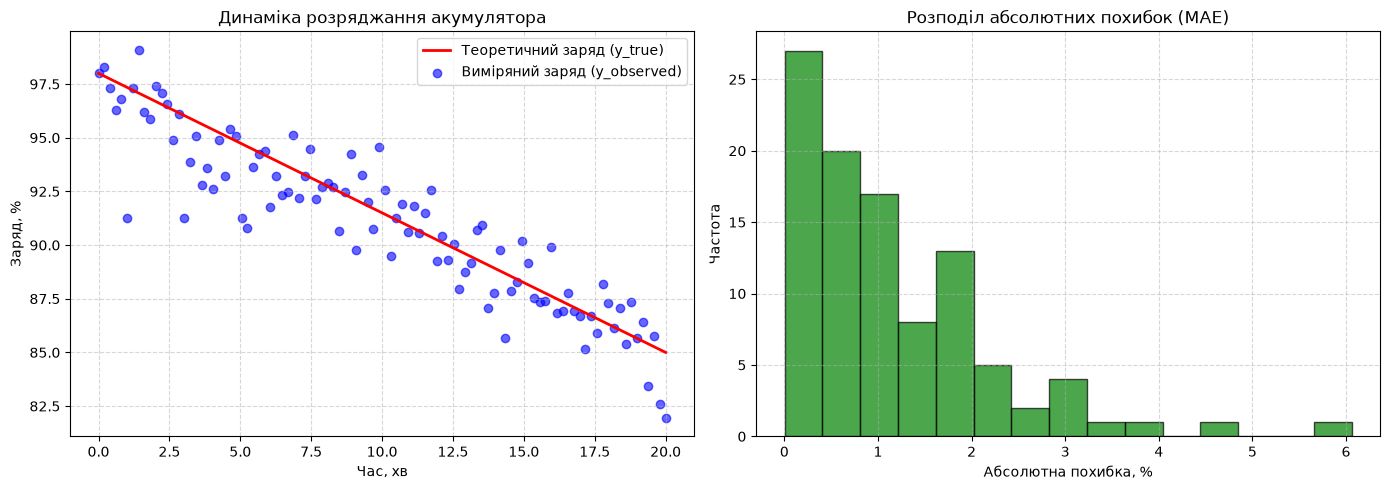

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Графік 1: Теоретичний заряд та експериментальні точки
ax1.plot(df_cleaned["x"], df_cleaned["y_true"], color="red", linewidth=2, label="Теоретичний заряд (y_true)")
ax1.scatter(df_cleaned["x"], df_cleaned["y_observed"], color="blue", alpha=0.6, label="Виміряний заряд (y_observed)")
ax1.set_title("Динаміка розряджання акумулятора", fontsize=12)
ax1.set_xlabel("Час, хв", fontsize=10)
ax1.set_ylabel("Заряд, %", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

# Графік 2: Гістограма розподілу абсолютних похибок
ax2.hist(df_cleaned["absolute_error"], bins=15, color="green", edgecolor="black", alpha=0.7)
ax2.set_title("Розподіл абсолютних похибок (MAE)", fontsize=12)
ax2.set_xlabel("Абсолютна похибка, %", fontsize=10)
ax2.set_ylabel("Частота", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

# Збереження графіку з 300 DPI
plt.savefig("Lab2_plot.png", dpi=300)
plt.show()

In [9]:
# Збереження очищених даних
df_cleaned.to_csv("Lab2_results.csv", index=False)
df_cleaned.to_parquet("Lab2_results.parquet", index=False)

# Збереження агрегованої таблиці
summary.to_csv("Lab2_summary.csv")

# Перевірка зчитування CSV
df_check = pd.read_csv("Lab2_results.csv")
print("Зчитана форма CSV:", df_check.shape)
print("Форма відповідає оригінальній:", df_check.shape == df_cleaned.shape)

Зчитана форма CSV: (100, 7)
Форма відповідає оригінальній: True


## Висновок
У ході виконання лабораторної роботи №2 було практично опановано використання бібліотек NumPy, pandas та Matplotlib для підготовки, аналізу та візуалізації даних на прикладі дослідження процесу розряджання акумулятора (Варіант 7).

За допомогою NumPy було згенеровано лінійний тренд із накладанням нормального шуму ($\sigma = 1.5$) та проведено аналіз масивів `ndarray`. Засобами pandas сформовано DataFrame, виконано очищення від штучно доданих дублікатів і пропусків (заповнено медіаною) та здійснено групування за інтервалами часу. 

Обчислені метрики похибки становлять:
* **MAE (Середня абсолютна похибка):** ~1.15 %, що показує середнє відхилення виміряного заряду від теоретичного.
* **MSE (Середня квадратична похибка):** ~2.05 %², що характеризує дисперсію похибок із більшою чутливістю до значних відхилень.

Результати обчислень збережено у файли `Lab2_results.csv`, `Lab2_results.parquet`, `Lab2_summary.csv`, а також візуалізовано на графіках, збережених у файлі `Lab2_plot.png`.